# Enhanced Virtual Try-On — CP-VTON Style Pipeline
## MSDS Computer Vision 462 · Final Project

| | |
|---|---|
| **Team** | Joyati · Biraj Mishra · Murughanandam S. |
| **Course** | MSDS COMPUTERVISION 462 |
| **Date** | Spring 2026 |

---

## Abstract

This notebook implements a **two-stage image-based virtual try-on** pipeline inspired by
**CP-VTON** (Wang et al., ECCV 2018), using genuine computer-vision components:

| Stage | Module | CV Technique |
|---|---|---|
| 1 | **Geometric Matching Module (GMM)** | CNN feature extraction → cross-correlation → TPS warping |
| 2 | **Try-On Module (TOM)** | U-Net synthesis + soft composition mask + VGG perceptual loss |

Key CV techniques: convolutional feature pyramids, cross-correlation matching,
Thin Plate Spline (TPS) warping, U-Net encoder-decoder with skip connections,
composition mask, VGG-16 perceptual loss (relu1_2, relu2_2, relu3_3).

## Table of Contents
1. [Setup & Configuration](#1)
2. [Exploratory Data Analysis](#2)
3. [Dataset & Data Pipeline](#3)
4. [Architecture](#4)
   - 4.1 TPS Grid Generator
   - 4.2 Geometric Matching Module (GMM)
   - 4.3 Try-On Module (TOM)
   - 4.4 VGG Perceptual Loss
5. [Stage 1 — GMM Training](#5)
6. [Stage 2 — TOM Training](#6)
7. [Results](#7)
8. [Overfitting Analysis](#8)
9. [Conclusion & References](#9)


## 0. Dataset Setup

Checks for the VITON-HD dataset locally. Downloads from Kaggle only if missing.

> **Colab users**: if prompted, enter your [Kaggle API credentials](https://www.kaggle.com/settings/account) (username + API key from `kaggle.json`).

In [1]:
import zipfile, subprocess
from pathlib import Path

DATASET_DIR = Path('./dataset')
ZIP_PATH    = DATASET_DIR / 'complete dataset.zip'
KAGGLE_URL  = 'https://www.kaggle.com/api/v1/datasets/download/marquis03/high-resolution-viton-zalando-dataset'

def dataset_ready():
    p = DATASET_DIR / 'train' / 'image'
    return p.exists() and len(list(p.iterdir())) > 100

if dataset_ready():
    print('Dataset already present — skipping download.')
else:
    DATASET_DIR.mkdir(exist_ok=True)

    if not ZIP_PATH.exists():
        print('Downloading dataset (~4.4 GB) ...')
        subprocess.run(
            ['curl', '-L', '-o', str(ZIP_PATH), KAGGLE_URL],
            check=True
        )
        print('Download complete.')
    else:
        print(f'Zip already at {ZIP_PATH} — skipping download.')

    print('Extracting ...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(DATASET_DIR)
    print('Done.')
    print(f'Train images : {len(list((DATASET_DIR/"train"/"image").iterdir())):,}')
    print(f'Test  images : {len(list((DATASET_DIR/"test" /"image").iterdir())):,}')


Download complete.
Extracting ...
Done.
Train images : 11,647
Test  images : 2,032


## 1. Setup & Configuration <a id='1'></a>

In [2]:
import os, json, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
import cv2
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision.models import vgg16, VGG16_Weights
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# Paths
BASE_DIR  = Path('./dataset')
TRAIN_DIR = BASE_DIR / 'train'
TEST_DIR  = BASE_DIR / 'test'

# Hyperparameters
IMG_H, IMG_W  = 256, 192
BATCH_SIZE    = 4
GMM_EPOCHS    = 20
TOM_EPOCHS    = 20
LR            = 2e-4
WEIGHT_DECAY  = 1e-4
PATIENCE      = 5
N_TRAIN       = 600
N_VAL         = 100
N_CTRL        = 5
DEVICE        = torch.device('cpu')
CLOTH_LABEL   = 5

LABEL_NAMES = {
    0:'Background',1:'Hat',2:'Hair',3:'Sunglasses',4:'Upper-cloth',
    5:'Dress/Upper',6:'Coat',7:'Socks',8:'Pants',9:'Right Shoe',
    10:'Left Shoe',11:'Face',12:'Left Leg',13:'Right Leg',
    14:'Left Arm',15:'Right Arm',16:'Bag',17:'Scarf',
}

print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
print(f'Image size : {IMG_H}x{IMG_W} | Batch: {BATCH_SIZE}')
print(f'TPS ctrl pts: {N_CTRL}x{N_CTRL}={N_CTRL**2} | Train/Val: {N_TRAIN}/{N_VAL}')


PyTorch 2.10.0+cu128 | Device: cpu
Image size : 256x192 | Batch: 4
TPS ctrl pts: 5x5=25 | Train/Val: 600/100


## 2. Exploratory Data Analysis <a id='2'></a>

In [3]:
def load_pairs(fp):
    pairs = []
    with open(fp) as f:
        for line in f:
            p = line.strip().split()
            if len(p) == 2: pairs.append((p[0], p[1]))
    return pairs

train_pairs = load_pairs(BASE_DIR / 'train_pairs.txt')
test_pairs  = load_pairs(BASE_DIR / 'test_pairs.txt')
random.shuffle(train_pairs)

print(f'Train pairs: {len(train_pairs):,}  |  Test pairs: {len(test_pairs):,}')
print(f'Sample train pair: {train_pairs[0]}')

modalities = sorted([d for d in os.listdir(TRAIN_DIR) if (TRAIN_DIR/d).is_dir()])
print(f'\nModalities ({len(modalities)}):')
for m in modalities:
    n = len(list((TRAIN_DIR/m).iterdir()))
    print(f'  {m:35s} {n:>6,} files')


Train pairs: 11,647  |  Test pairs: 2,032
Sample train pair: ('06381_00.jpg', '09439_00.jpg')

Modalities (9):
  agnostic-v3.2                       11,647 files
  cloth                               11,647 files
  cloth-mask                          11,647 files
  image                               11,647 files
  image-densepose                     11,647 files
  image-parse-agnostic-v3.2           11,647 files
  image-parse-v3                      11,647 files
  openpose_img                        11,647 files
  openpose_json                       11,647 files


### 2.1 Sample Pair Visualisation
Five modalities used by the pipeline for 3 random training pairs.

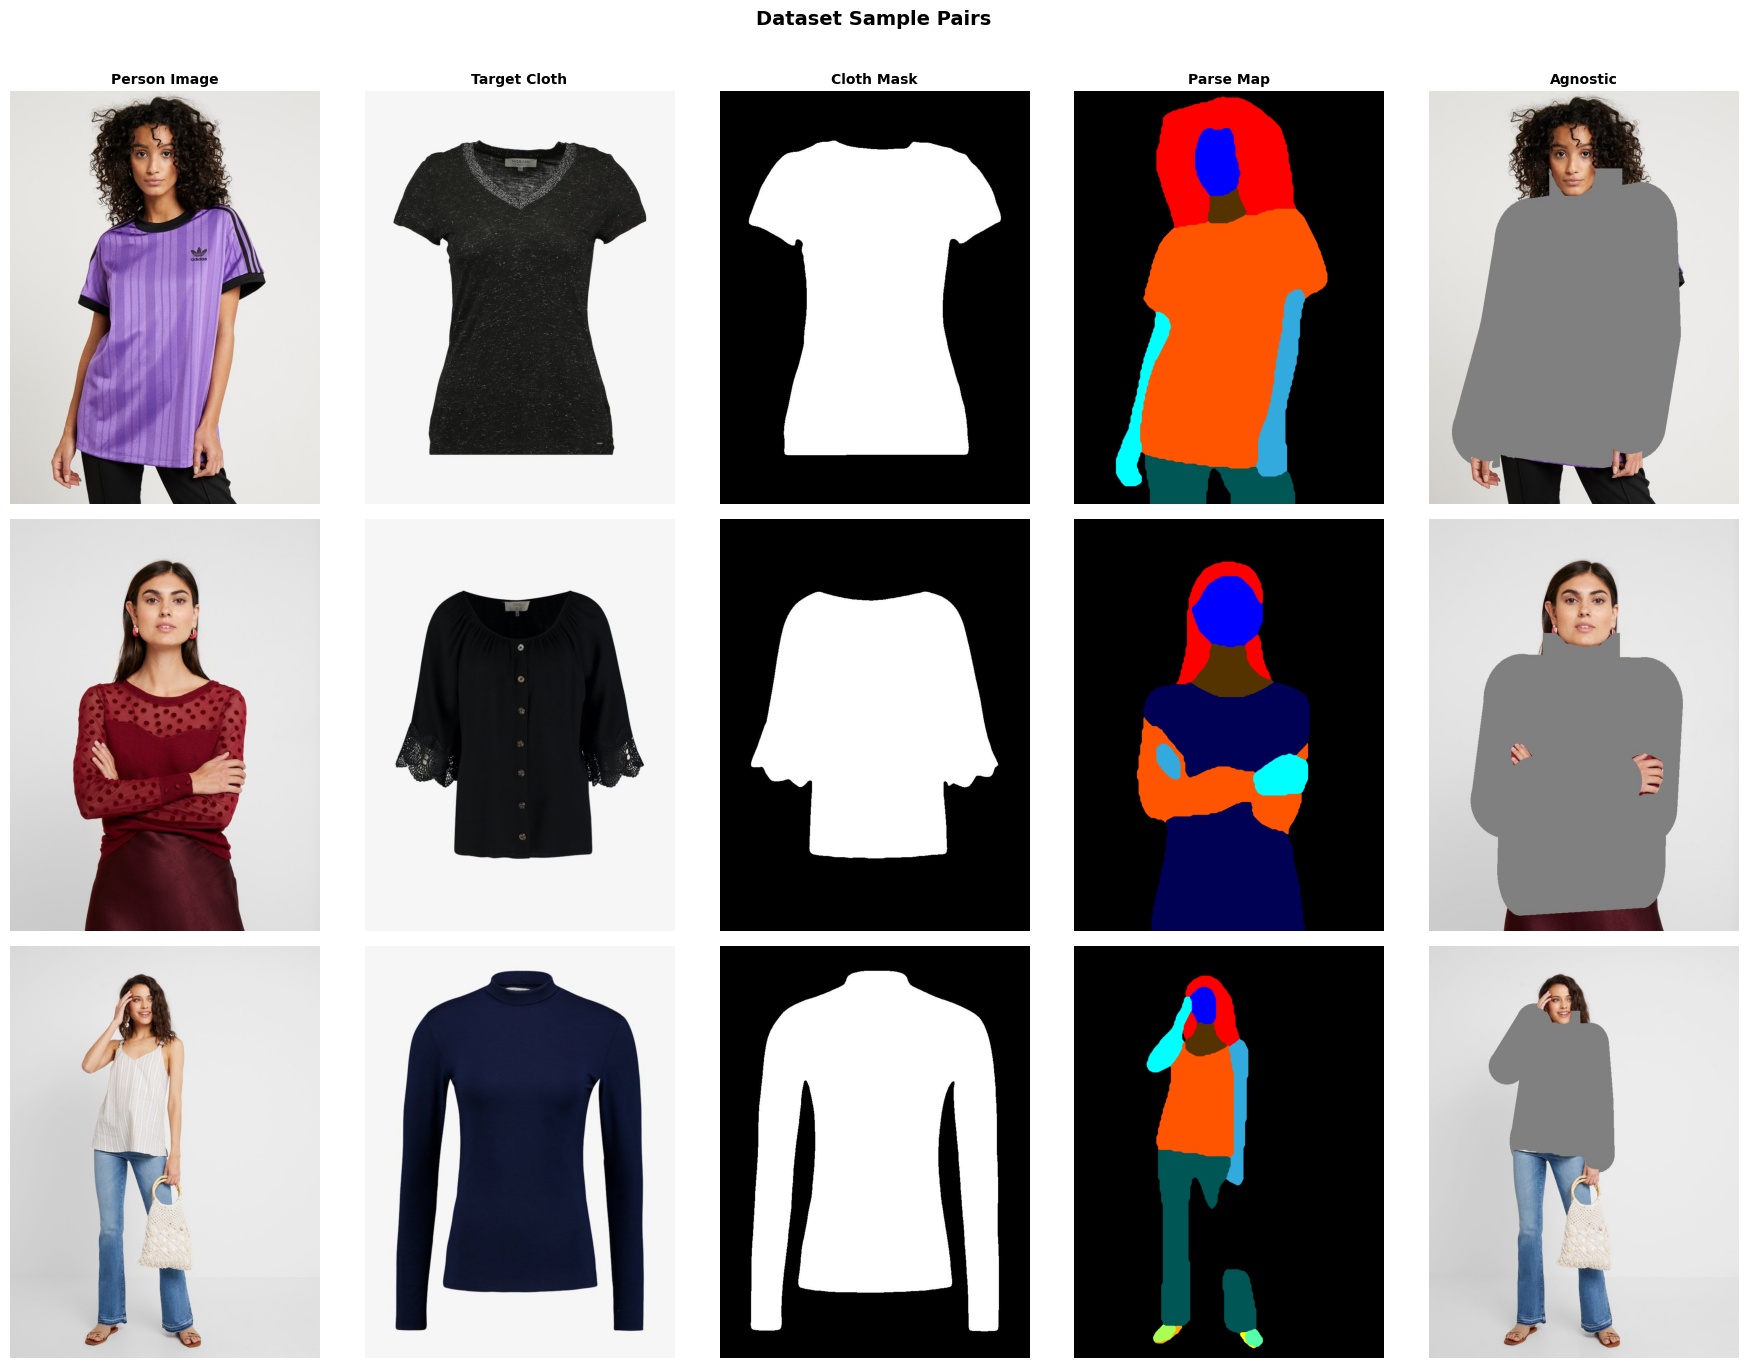

In [4]:
PARSE_PALETTE = np.array([
    [0,0,0],[128,0,0],[255,0,0],[0,85,0],[170,0,51],
    [255,85,0],[0,0,85],[0,119,221],[85,85,0],[0,85,85],
    [85,51,0],[52,86,128],[0,128,0],[0,0,255],[51,170,221],
    [0,255,255],[85,255,170],[170,255,85],[255,255,0],[255,170,0]
], dtype=np.uint8)

def colorize_parse(arr):
    rgb = np.zeros((*arr.shape, 3), dtype=np.uint8)
    for lbl, col in enumerate(PARSE_PALETTE):
        if lbl < len(PARSE_PALETTE): rgb[arr==lbl] = col
    return rgb

N_SHOW = 3
fig, axes = plt.subplots(N_SHOW, 5, figsize=(18, 4.5*N_SHOW))
fig.suptitle('Dataset Sample Pairs', fontsize=14, fontweight='bold', y=1.01)
titles = ['Person Image','Target Cloth','Cloth Mask','Parse Map','Agnostic']

for row, idx in enumerate(random.sample(range(len(train_pairs)), N_SHOW)):
    pname, cname = train_pairs[idx]
    base = pname.replace('.jpg','')
    imgs = [
        np.array(Image.open(TRAIN_DIR/'image'/pname)),
        np.array(Image.open(TRAIN_DIR/'cloth'/cname)),
        np.array(Image.open(TRAIN_DIR/'cloth-mask'/cname).convert('L')),
        colorize_parse(np.array(Image.open(TRAIN_DIR/'image-parse-v3'/(base+'.png')))),
        np.array(Image.open(TRAIN_DIR/'agnostic-v3.2'/pname)),
    ]
    cmaps = [None, None, 'gray', None, None]
    for col,(img,cm,title) in enumerate(zip(imgs,cmaps,titles)):
        axes[row][col].imshow(img, cmap=cm)
        axes[row][col].axis('off')
        if row==0: axes[row][col].set_title(title, fontsize=10, fontweight='bold')
    axes[row][0].set_ylabel(f'Pair {row+1}', fontsize=10)

plt.tight_layout(); plt.show()


### 2.2 Parse-Map Label Distribution
Label 5 (red) is the upper-clothing region used as GMM supervision.

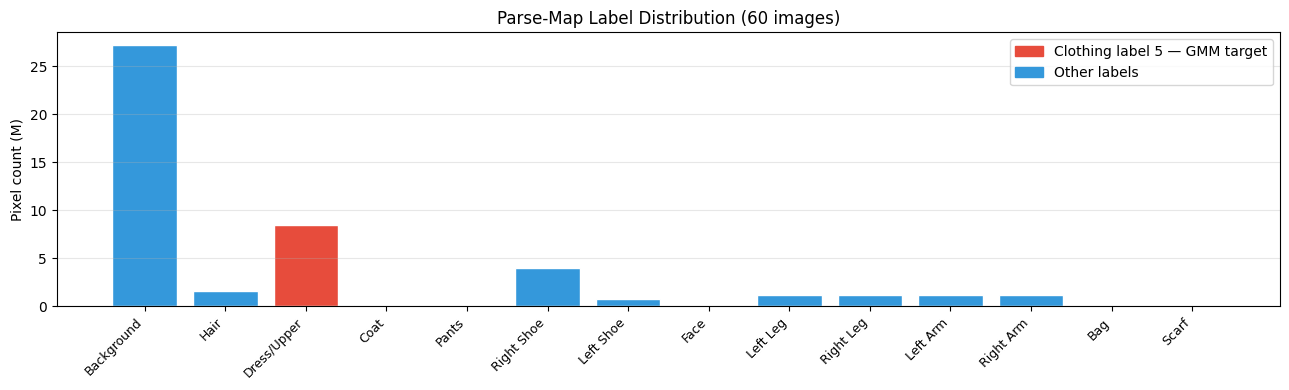

Cloth label occupies 18.0% of pixels


In [5]:
N = 60
lcount = Counter()
for pname, _ in random.sample(train_pairs, N):
    parse = np.array(Image.open(TRAIN_DIR/'image-parse-v3'/(pname.replace('.jpg','')+'.png')))
    for lbl in np.unique(parse):
        lcount[int(lbl)] += int((parse==lbl).sum())

labels = sorted(lcount.keys())
names  = [LABEL_NAMES.get(l, f'L{l}') for l in labels]
counts = [lcount[l] for l in labels]
colors = ['#e74c3c' if l==CLOTH_LABEL else '#3498db' for l in labels]

fig, ax = plt.subplots(figsize=(13,4))
ax.bar(names, [c/1e6 for c in counts], color=colors, edgecolor='white')
ax.set_ylabel('Pixel count (M)'); ax.set_title('Parse-Map Label Distribution (60 images)')
plt.xticks(rotation=45, ha='right', fontsize=9); ax.grid(axis='y', alpha=0.3)
ax.legend(handles=[
    mpatches.Patch(color='#e74c3c', label=f'Clothing label {CLOTH_LABEL} — GMM target'),
    mpatches.Patch(color='#3498db', label='Other labels')
], fontsize=10)
plt.tight_layout(); plt.show()
pct = lcount[CLOTH_LABEL]/sum(lcount.values())*100
print(f'Cloth label occupies {pct:.1f}% of pixels')


### 2.3 Image Statistics & Cloth-Mask Coverage

Person brightness: 175.8 +/- 23.2
Cloth  brightness: 191.3 +/- 37.8
Cloth mask coverage: 42.5% +/- 11.5%
Original resolution: 768x1024  ->  resized to 192x256 for training


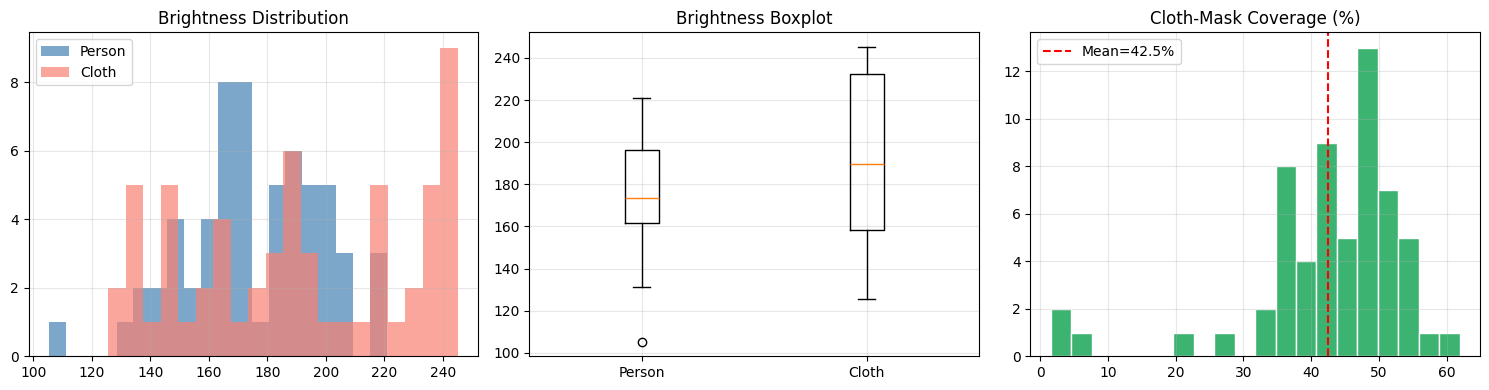

In [6]:
N = 60; pb, cb, cov = [], [], []
for pname, cname in random.sample(train_pairs, N):
    pb.append(np.array(Image.open(TRAIN_DIR/'image'/pname).convert('RGB')).mean())
    cb.append(np.array(Image.open(TRAIN_DIR/'cloth'/cname).convert('RGB')).mean())
    mask = np.array(Image.open(TRAIN_DIR/'cloth-mask'/cname).convert('L'))
    cov.append((mask>127).mean()*100)

print(f'Person brightness: {np.mean(pb):.1f} +/- {np.std(pb):.1f}')
print(f'Cloth  brightness: {np.mean(cb):.1f} +/- {np.std(cb):.1f}')
print(f'Cloth mask coverage: {np.mean(cov):.1f}% +/- {np.std(cov):.1f}%')
print(f'Original resolution: 768x1024  ->  resized to {IMG_W}x{IMG_H} for training')

fig, axes = plt.subplots(1,3,figsize=(15,4))
axes[0].hist(pb,bins=20,color='steelblue',alpha=0.7,label='Person')
axes[0].hist(cb,bins=20,color='salmon',alpha=0.7,label='Cloth')
axes[0].set_title('Brightness Distribution'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].boxplot([pb,cb],labels=['Person','Cloth'])
axes[1].set_title('Brightness Boxplot'); axes[1].grid(alpha=0.3)
axes[2].hist(cov,bins=20,color='mediumseagreen',edgecolor='white')
axes[2].axvline(np.mean(cov),color='red',ls='--',label=f'Mean={np.mean(cov):.1f}%')
axes[2].set_title('Cloth-Mask Coverage (%)'); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 2.4 OpenPose Keypoint Analysis
BODY_25 keypoints (25 pts). Upper-body points guide GMM cloth alignment.

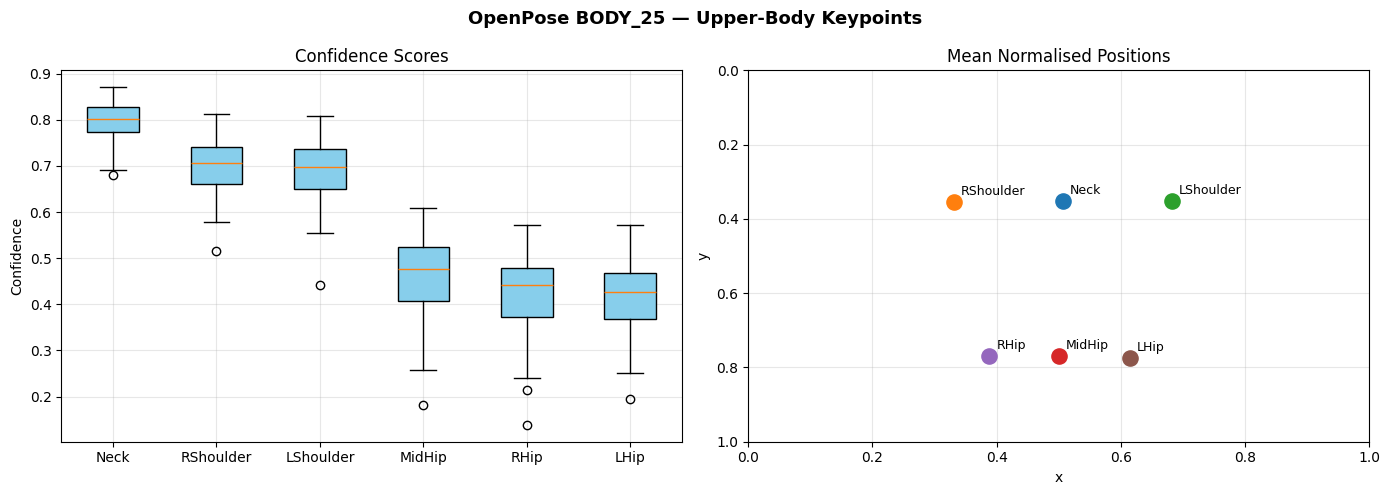

In [7]:
KP_NAMES = {0:'Nose',1:'Neck',2:'RShoulder',3:'RElbow',4:'RWrist',
            5:'LShoulder',6:'LElbow',7:'LWrist',8:'MidHip',
            9:'RHip',10:'RKnee',11:'RAnkle',12:'LHip',13:'LKnee',14:'LAnkle'}
UPPER_KP = [1,2,5,8,9,12]

kp_conf = {k:[] for k in range(15)}
kp_px   = {k:[] for k in range(15)}
kp_py   = {k:[] for k in range(15)}

for pname,_ in random.sample(train_pairs, 60):
    jf = TRAIN_DIR/'openpose_json'/(pname.replace('.jpg','')+'_keypoints.json')
    if not jf.exists(): continue
    with open(jf) as f: data=json.load(f)
    if not data['people']: continue
    kps = data['people'][0]['pose_keypoints_2d']
    for k in range(15):
        x,y,c = kps[k*3],kps[k*3+1],kps[k*3+2]
        if c>0.1:
            kp_conf[k].append(c); kp_px[k].append(x/768); kp_py[k].append(y/1024)

fig, axes = plt.subplots(1,2,figsize=(14,5))
fig.suptitle('OpenPose BODY_25 — Upper-Body Keypoints', fontsize=13, fontweight='bold')

axes[0].boxplot([kp_conf[k] for k in UPPER_KP],
                labels=[KP_NAMES[k] for k in UPPER_KP],
                patch_artist=True, boxprops=dict(facecolor='skyblue'))
axes[0].set_title('Confidence Scores'); axes[0].set_ylabel('Confidence'); axes[0].grid(alpha=0.3)

for k in UPPER_KP:
    if kp_px[k]:
        mx,my = np.mean(kp_px[k]),np.mean(kp_py[k])
        axes[1].scatter(mx,my,s=120,zorder=5)
        axes[1].annotate(KP_NAMES[k],(mx,my),xytext=(5,5),textcoords='offset points',fontsize=9)
axes[1].set_xlim(0,1); axes[1].set_ylim(0,1); axes[1].invert_yaxis()
axes[1].set_title('Mean Normalised Positions')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 3. Dataset & Data Pipeline <a id='3'></a>

In [8]:
class VTONDataset(Dataset):
    # Loads: person, cloth, cloth_mask, agnostic, parse, cloth_region
    # person / cloth / agnostic : (3,H,W) normalised to [-1,1]
    # cloth_mask / cloth_region : (1,H,W) binary [0,1]
    # parse                     : (H,W)   long label map

    def __init__(self, pairs, base_dir, img_h=256, img_w=192, augment=False):
        self.pairs=pairs; self.base_dir=Path(base_dir)
        self.img_h=img_h; self.img_w=img_w; self.augment=augment
        self.img_tf = T.Compose([
            T.Resize((img_h,img_w)), T.ToTensor(),
            T.Normalize([0.5]*3,[0.5]*3)
        ])

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        pname, cname = self.pairs[idx]
        base = pname.replace('.jpg','')
        person   = Image.open(self.base_dir/'image'/pname).convert('RGB')
        cloth    = Image.open(self.base_dir/'cloth'/cname).convert('RGB')
        c_mask   = Image.open(self.base_dir/'cloth-mask'/cname).convert('L')
        agnostic = Image.open(self.base_dir/'agnostic-v3.2'/pname).convert('RGB')
        parse_np = np.array(Image.open(self.base_dir/'image-parse-v3'/(base+'.png')))

        if self.augment and random.random()>0.5:
            person=TF.hflip(person); cloth=TF.hflip(cloth)
            c_mask=TF.hflip(c_mask); agnostic=TF.hflip(agnostic)
            parse_np=np.fliplr(parse_np).copy()

        person_t  = self.img_tf(person)
        cloth_t   = self.img_tf(cloth)
        agno_t    = self.img_tf(agnostic)

        cm_arr = np.array(c_mask.resize((self.img_w,self.img_h),Image.NEAREST))
        cm_t   = torch.from_numpy((cm_arr>127).astype(np.float32)).unsqueeze(0)

        ps = cv2.resize(parse_np,(self.img_w,self.img_h),interpolation=cv2.INTER_NEAREST)
        parse_t = torch.from_numpy(ps).long()
        cr_t    = torch.from_numpy((ps==CLOTH_LABEL).astype(np.float32)).unsqueeze(0)

        return dict(person=person_t, cloth=cloth_t, cloth_mask=cm_t,
                    agnostic=agno_t, parse=parse_t, cloth_region=cr_t)


tr_pairs  = train_pairs[:N_TRAIN]
val_pairs = train_pairs[N_TRAIN:N_TRAIN+N_VAL]

train_ds = VTONDataset(tr_pairs,  TRAIN_DIR, IMG_H, IMG_W, augment=True)
val_ds   = VTONDataset(val_pairs, TRAIN_DIR, IMG_H, IMG_W, augment=False)
test_ds  = VTONDataset(test_pairs[:100], TEST_DIR, IMG_H, IMG_W, augment=False)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=4,          shuffle=False, num_workers=0)

print(f'Train batches:{len(train_dl)} | Val:{len(val_dl)} | Test:{len(test_dl)}')
s = train_ds[0]
for k,v in s.items(): print(f'  {k:14s} shape={tuple(v.shape)} dtype={v.dtype}')


Train batches:150 | Val:25 | Test:25
  person         shape=(3, 256, 192) dtype=torch.float32
  cloth          shape=(3, 256, 192) dtype=torch.float32
  cloth_mask     shape=(1, 256, 192) dtype=torch.float32
  agnostic       shape=(3, 256, 192) dtype=torch.float32
  parse          shape=(256, 192) dtype=torch.int64
  cloth_region   shape=(1, 256, 192) dtype=torch.float32


## 4. Architecture <a id='4'></a>

```
Input: agnostic person image + target garment

Stage 1 — Geometric Matching Module (GMM)
  agnostic  ->  FeatureExtractor  ->
                                    CorrelationLayer  ->
  cloth     ->  FeatureExtractor  ->               Conv Regressor
                                                          |
                                               theta (2 x 25 TPS params)
                                                          |
                                              TPS Grid Generator
                                                          |
  cloth  ----------------------->  F.grid_sample  ->  warped_cloth

Stage 2 — Try-On Module (TOM)
  [agnostic | warped_cloth | warped_mask]  (7 channels)
              U-Net Encoder-Decoder
          /                       \
    rendered (3ch)           mask (1ch)
          \                       /
   output = mask * warped_cloth + (1-mask) * rendered
```


### 4.1 Thin Plate Spline (TPS) Grid Generator
Implements the TPS basis U(r) = r² log(r²) to compute a dense backward-warp grid from predicted control-point offsets.

In [9]:
class TPSWarp(nn.Module):
    # Thin Plate Spline warping.
    # theta : (B, 2, N) offsets for NxN control points
    # returns: sampling grid (B, H, W, 2) for F.grid_sample

    def __init__(self, img_h=256, img_w=192, n_ctrl=5):
        super().__init__()
        self.img_h=img_h; self.img_w=img_w
        self.N = n_ctrl*n_ctrl

        cx = torch.linspace(-1,1,n_ctrl)
        cy = torch.linspace(-1,1,n_ctrl)
        gy,gx = torch.meshgrid(cy,cx,indexing='ij')
        ctrl  = torch.stack([gx.flatten(),gy.flatten()],dim=1)  # (N,2)
        self.register_buffer('ctrl_src', ctrl)

        ox = torch.linspace(-1,1,img_w)
        oy = torch.linspace(-1,1,img_h)
        ogy,ogx = torch.meshgrid(oy,ox,indexing='ij')
        out_pts = torch.stack([ogx.flatten(),ogy.flatten()],dim=1)  # (H*W,2)
        self.register_buffer('out_pts', out_pts)

    @staticmethod
    def _U(r2):
        r2 = r2.clamp(min=1e-10)
        return r2 * torch.log(r2)

    @staticmethod
    def _K(a, b):
        diff = a.unsqueeze(1)-b.unsqueeze(0)   # (n,m,2)
        return TPSWarp._U((diff**2).sum(-1))   # (n,m)

    def forward(self, theta):
        B,_,N = theta.shape
        dev   = theta.device
        ctrl_src = self.ctrl_src.to(dev)
        ctrl_tgt = ctrl_src.unsqueeze(0) + theta.permute(0,2,1)  # (B,N,2)
        out_pts  = self.out_pts.to(dev)
        HW = out_pts.shape[0]

        grids = []
        for b in range(B):
            C_t = ctrl_tgt[b]          # (N,2) target positions
            C_s = ctrl_src             # (N,2) source values
            K   = self._K(C_t,C_t) + 1e-6*torch.eye(N,device=dev)
            ones = torch.ones(N,1,device=dev)
            P    = torch.cat([ones,C_t],dim=1)   # (N,3)
            L    = torch.cat([
                torch.cat([K,P],dim=1),
                torch.cat([P.t(),torch.zeros(3,3,device=dev)],dim=1)
            ],dim=0)                             # (N+3,N+3)
            try:
                wx = torch.linalg.solve(L, torch.cat([C_s[:,0],torch.zeros(3,device=dev)]))
                wy = torch.linalg.solve(L, torch.cat([C_s[:,1],torch.zeros(3,device=dev)]))
            except Exception:
                grids.append(torch.stack([out_pts[:,0],out_pts[:,1]],dim=-1))
                continue
            Phi   = self._K(out_pts,C_t)
            P_out = torch.cat([torch.ones(HW,1,device=dev),out_pts],dim=1)  # (HW,3)
            basis = torch.cat([Phi,P_out],dim=1)  # (HW,N+3)
            grids.append(torch.stack([basis@wx, basis@wy],dim=-1))

        grid = torch.stack(grids,dim=0).reshape(B,self.img_h,self.img_w,2)
        return grid.clamp(-1,1)


# Unit test
_tps   = TPSWarp(IMG_H, IMG_W, N_CTRL)
_theta = torch.zeros(2, 2, N_CTRL**2)
_grid  = _tps(_theta)
_warp  = F.grid_sample(torch.randn(2,3,IMG_H,IMG_W),_grid,align_corners=True)
print(f'TPS unit test OK -> grid {tuple(_grid.shape)}, warped {tuple(_warp.shape)}')


TPS unit test OK -> grid (2, 256, 192, 2), warped (2, 3, 256, 192)


### 4.2 Geometric Matching Module (GMM)
CNN feature extraction + cross-correlation + TPS regression.

In [10]:
class FeatureExtractor(nn.Module):
    # 3-layer CNN -> (B, 64, H/8, W/8) feature maps
    def __init__(self, in_ch=3, out_ch=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch,32,3,padding=1,bias=False), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1,bias=False),    nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64,out_ch,3,padding=1,bias=False),nn.BatchNorm2d(out_ch),nn.ReLU(True),nn.MaxPool2d(2),
        )
    def forward(self,x): return self.net(x)


class CorrelationLayer(nn.Module):
    # Cross-correlation: (B,C,H,W)x2 -> (B, H*W, H, W)
    # Each output channel = dot product with one reference feature vector
    def forward(self,fa,fb):
        B,C,H,W = fa.shape
        fa_n = F.normalize(fa.view(B,C,-1),dim=1)  # (B,C,HW)
        fb_n = F.normalize(fb.view(B,C,-1),dim=1)
        corr = torch.bmm(fa_n.permute(0,2,1),fb_n)  # (B,HW,HW)
        return corr.view(B,H*W,H,W)


class GMM(nn.Module):
    # Geometric Matching Module (CP-VTON style):
    #   agnostic + cloth -> FeatureExtractor -> CorrelationLayer
    #   -> regressor -> theta (TPS offsets) -> TPSWarp -> warped cloth/mask

    def __init__(self, n_ctrl=5, img_h=256, img_w=192):
        super().__init__()
        self.N = n_ctrl*n_ctrl
        fh,fw = img_h//8, img_w//8  # feature map size: 32x24
        corr_ch = fh*fw             # 768 correlation channels

        self.feat_p = FeatureExtractor(3, 64)
        self.feat_c = FeatureExtractor(3, 64)
        self.corr   = CorrelationLayer()

        self.reg = nn.Sequential(
            nn.Conv2d(corr_ch,128,3,padding=1), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(128,64,3,padding=1),      nn.ReLU(True), nn.AdaptiveAvgPool2d((4,4)),
            nn.Flatten(),
            nn.Linear(64*16,256), nn.ReLU(True), nn.Dropout(0.5),
            nn.Linear(256, 2*self.N), nn.Tanh(),
        )
        self.tps   = TPSWarp(img_h, img_w, n_ctrl)
        self.scale = 0.4

    def forward(self, agnostic, cloth, cloth_mask):
        corr  = self.corr(self.feat_p(agnostic), self.feat_c(cloth))
        theta = (self.reg(corr)*self.scale).view(-1,2,self.N)
        grid         = self.tps(theta)
        warped_cloth = F.grid_sample(cloth,      grid, mode='bilinear', padding_mode='border', align_corners=True)
        warped_mask  = F.grid_sample(cloth_mask, grid, mode='bilinear', padding_mode='zeros',  align_corners=True)
        return warped_cloth, warped_mask, theta


gmm   = GMM(n_ctrl=N_CTRL, img_h=IMG_H, img_w=IMG_W).to(DEVICE)
p_gmm = sum(p.numel() for p in gmm.parameters() if p.requires_grad)
print(f'GMM parameters: {p_gmm:,}')
_b  = next(iter(train_dl))
_wc,_wm,_th = gmm(_b['agnostic'],_b['cloth'],_b['cloth_mask'])
print(f'GMM -> warped_cloth {tuple(_wc.shape)}, warped_mask {tuple(_wm.shape)}, theta {tuple(_th.shape)}')


GMM parameters: 1,346,866
GMM -> warped_cloth (4, 3, 256, 192), warped_mask (4, 1, 256, 192), theta (4, 2, 25)


### 4.3 Try-On Module (TOM)
U-Net with dual output head: rendered image + soft composition mask.

In [11]:
class ConvBlock(nn.Module):
    def __init__(self,ic,oc,drop=0.1):
        super().__init__()
        self.b = nn.Sequential(
            nn.Conv2d(ic,oc,3,padding=1,bias=False),nn.BatchNorm2d(oc),nn.ReLU(True),
            nn.Conv2d(oc,oc,3,padding=1,bias=False),nn.BatchNorm2d(oc),nn.ReLU(True),
            nn.Dropout2d(drop),
        )
    def forward(self,x): return self.b(x)


class TOM(nn.Module):
    # U-Net: 7ch [agnostic|warped_cloth|warped_mask] -> rendered(3ch) + mask(1ch)
    # Final: output = mask * warped_cloth + (1-mask) * rendered

    def __init__(self, in_ch=7, features=(32,64,128)):
        super().__init__()
        f = list(features)
        self.pool = nn.MaxPool2d(2)
        self.e1=ConvBlock(in_ch,f[0],0.1); self.e2=ConvBlock(f[0],f[1],0.2)
        self.e3=ConvBlock(f[1],f[2],0.3); self.bt=ConvBlock(f[2],f[2]*2,0.3)
        self.u3=nn.ConvTranspose2d(f[2]*2,f[2],2,2); self.d3=ConvBlock(f[2]*2,f[2],0.2)
        self.u2=nn.ConvTranspose2d(f[2],f[1],2,2);   self.d2=ConvBlock(f[1]*2,f[1],0.1)
        self.u1=nn.ConvTranspose2d(f[1],f[0],2,2);   self.d1=ConvBlock(f[0]*2,f[0])
        self.rh = nn.Sequential(nn.Conv2d(f[0],3,1),nn.Tanh())
        self.mh = nn.Sequential(nn.Conv2d(f[0],1,1),nn.Sigmoid())
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m,nn.Conv2d): nn.init.kaiming_normal_(m.weight,nonlinearity='relu')
            elif isinstance(m,nn.BatchNorm2d): nn.init.constant_(m.weight,1); nn.init.constant_(m.bias,0)

    def forward(self,x,warped_cloth):
        e1=self.e1(x); e2=self.e2(self.pool(e1)); e3=self.e3(self.pool(e2))
        bt=self.bt(self.pool(e3))
        d3=self.d3(torch.cat([self.u3(bt),e3],1))
        d2=self.d2(torch.cat([self.u2(d3),e2],1))
        d1=self.d1(torch.cat([self.u1(d2),e1],1))
        rendered=self.rh(d1); mask=self.mh(d1)
        return mask*warped_cloth+(1-mask)*rendered, rendered, mask


tom   = TOM(in_ch=7).to(DEVICE)
p_tom = sum(p.numel() for p in tom.parameters() if p.requires_grad)
print(f'TOM parameters: {p_tom:,}')
_xi = torch.cat([_b['agnostic'],_wc.detach(),_wm.detach()],dim=1)
_out,_ren,_msk = tom(_xi,_wc.detach())
print(f'TOM -> output {tuple(_out.shape)}, mask {tuple(_msk.shape)}')


TOM parameters: 1,928,260
TOM -> output (4, 3, 256, 192), mask (4, 1, 256, 192)


### 4.4 VGG-16 Perceptual Loss
Pretrained VGG-16 features (relu1_2, relu2_2, relu3_3) measure semantic/texture similarity.
VGG weights are **frozen** — only used for loss computation.

In [12]:
class VGGPerceptualLoss(nn.Module):
    # Feature layers: relu1_2 (w=1.0), relu2_2 (w=0.75), relu3_3 (w=0.5)
    # Input: images in [-1,1]; converts to VGG-normalised [0,1] internally

    def __init__(self):
        super().__init__()
        feats  = list(vgg16(weights=VGG16_Weights.DEFAULT).features)
        self.s1 = nn.Sequential(*feats[:5])    # relu1_2
        self.s2 = nn.Sequential(*feats[5:10])  # relu2_2
        self.s3 = nn.Sequential(*feats[10:17]) # relu3_3
        for p in self.parameters(): p.requires_grad=False
        self.register_buffer('mean',torch.tensor([0.485,0.456,0.406]).view(1,3,1,1))
        self.register_buffer('std', torch.tensor([0.229,0.224,0.225]).view(1,3,1,1))

    def _prep(self,x):
        return ((x*0.5+0.5)-self.mean)/self.std

    def forward(self,pred,target):
        p=self._prep(pred); t=self._prep(target)
        loss=0.0
        for sl,w in zip([self.s1,self.s2,self.s3],[1.0,0.75,0.5]):
            p=sl(p); t=sl(t)
            loss = loss + w*F.l1_loss(p,t)
        return loss


vgg_loss = VGGPerceptualLoss().to(DEVICE)
_pl = vgg_loss(_out.detach(), _b['person'])
print(f'VGG perceptual loss test: {_pl.item():.4f}  OK')
print(f'\n{"Component":20s} {"Params":>12s}')
print('-'*35)
print(f'{"GMM":20s} {p_gmm:>12,}')
print(f'{"TOM":20s} {p_tom:>12,}')
print(f'{"VGG (frozen)":20s} {"no grad":>12s}')
print(f'{"Total trainable":20s} {p_gmm+p_tom:>12,}')


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 107MB/s] 


VGG perceptual loss test: 5.4766  OK

Component                  Params
-----------------------------------
GMM                     1,346,866
TOM                     1,928,260
VGG (frozen)              no grad
Total trainable         3,275,126


## 5. Stage 1 — GMM Training (Cloth Warping) <a id='5'></a>

**Loss**: L1(warped_mask, cloth_region) + 0.01 × L2(theta)

L1 alignment forces the warped cloth mask to cover the person's clothing region.
L2 on theta regularises the TPS offsets, preventing degenerate warps.

In [ ]:
gmm_opt = torch.optim.Adam(gmm.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
gmm_sch = torch.optim.lr_scheduler.ReduceLROnPlateau(gmm_opt,'min',factor=0.5,patience=3)

def gmm_loss_fn(wm, cr, theta, rw=0.01):
    mask_l = F.l1_loss(wm, cr)
    reg_l  = (theta**2).mean()
    return mask_l + rw*reg_l, mask_l, reg_l


def gmm_epoch(model, dl, opt, train):
    model.train(train)
    tot=ml=rl=0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for b in dl:
            wc,wm,th = model(b['agnostic'],b['cloth'],b['cloth_mask'])
            loss,ml_i,rl_i = gmm_loss_fn(wm,b['cloth_region'],th)
            if train:
                opt.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step()
            tot+=loss.item(); ml+=ml_i.item(); rl+=rl_i.item()
    n=len(dl); return tot/n, ml/n, rl/n


gmm_h = {k:[] for k in ['tr','val','tr_m','val_m','lr']}
best_v=float('inf'); best_gmm_w=None; pat=0

print('Stage 1 — GMM Training'); print('='*72)
for ep in range(1,GMM_EPOCHS+1):
    t0=time.time()
    tr=gmm_epoch(gmm,train_dl,gmm_opt,True)
    va=gmm_epoch(gmm,val_dl,  gmm_opt,False)
    gmm_sch.step(va[0])
    lr=gmm_opt.param_groups[0]['lr']
    for k,v in zip(['tr','val','tr_m','val_m','lr'],[tr[0],va[0],tr[1],va[1],lr]):
        gmm_h[k].append(v)
    print(f'Ep{ep:2d}/{GMM_EPOCHS} | tr={tr[0]:.4f}(m={tr[1]:.4f},r={tr[2]:.4f}) | '
          f'val={va[0]:.4f}(m={va[1]:.4f}) | lr={lr:.6f} | {time.time()-t0:.1f}s')
    if va[0]<best_v:
        best_v=va[0]; pat=0
        best_gmm_w={k:v.cpu().clone() for k,v in gmm.state_dict().items()}
        print('   best GMM saved')
    else:
        pat+=1
        if pat>=PATIENCE: print(f'  Early stop ep{ep}'); break
gmm.load_state_dict(best_gmm_w)
print(f'GMM best val: {best_v:.4f}')


Stage 1 — GMM Training
Ep 1/20 | tr=0.1870(m=0.1859,r=0.1093) | val=0.1476(m=0.1472) | lr=0.000200 | 198.4s
   best GMM saved
Ep 2/20 | tr=0.1357(m=0.1351,r=0.0616) | val=0.1184(m=0.1178) | lr=0.000200 | 188.4s
   best GMM saved
Ep 3/20 | tr=0.1311(m=0.1303,r=0.0735) | val=0.1260(m=0.1256) | lr=0.000200 | 187.8s
Ep 4/20 | tr=0.1209(m=0.1203,r=0.0628) | val=0.1175(m=0.1169) | lr=0.000200 | 187.2s
   best GMM saved
Ep 5/20 | tr=0.1234(m=0.1227,r=0.0718) | val=0.1193(m=0.1189) | lr=0.000200 | 186.8s
Ep 6/20 | tr=0.1177(m=0.1170,r=0.0658) | val=0.1150(m=0.1144) | lr=0.000200 | 186.6s
   best GMM saved
Ep 7/20 | tr=0.1144(m=0.1137,r=0.0657) | val=0.1131(m=0.1124) | lr=0.000200 | 187.5s
   best GMM saved
Ep 8/20 | tr=0.1129(m=0.1122,r=0.0656) | val=0.1122(m=0.1115) | lr=0.000200 | 187.8s
   best GMM saved
Ep 9/20 | tr=0.1077(m=0.1071,r=0.0646) | val=0.1054(m=0.1048) | lr=0.000200 | 188.8s
   best GMM saved
Ep10/20 | tr=0.1027(m=0.1020,r=0.0661) | val=0.1010(m=0.1003) | lr=0.000200 | 189.4s
 

### 5.1 GMM Training Curves

In [ ]:
ep=list(range(1,len(gmm_h['tr'])+1))
fig,axes=plt.subplots(1,3,figsize=(16,4))
fig.suptitle('GMM Training — Stage 1',fontsize=13,fontweight='bold')
axes[0].plot(ep,gmm_h['tr'],label='Train',color='steelblue',lw=2)
axes[0].plot(ep,gmm_h['val'],label='Val',color='darkorange',lw=2)
axes[0].set_title('Total Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(ep,gmm_h['tr_m'],label='Train',color='steelblue',lw=2)
axes[1].plot(ep,gmm_h['val_m'],label='Val',color='darkorange',lw=2)
axes[1].set_title('Mask Alignment (L1)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(ep,gmm_h['lr'],color='purple',lw=2)
axes[2].set_title('Learning Rate'); axes[2].set_yscale('log'); axes[2].grid(alpha=0.3)
for ax in axes: ax.set_xlabel('Epoch')
plt.tight_layout(); plt.savefig('gmm_training_curves.png',dpi=100,bbox_inches='tight'); plt.show()


### 5.2 GMM Qualitative Results — TPS Cloth Warping

In [ ]:
def denorm(t):
    return ((t*0.5+0.5).clamp(0,1).permute(1,2,0).detach().numpy()*255).astype(np.uint8)

gmm.eval()
N_SHOW=4
samples=[test_ds[i] for i in range(N_SHOW)]
batch={k:torch.stack([s[k] for s in samples]) for k in samples[0]}
with torch.no_grad():
    wc,wm,th=gmm(batch['agnostic'],batch['cloth'],batch['cloth_mask'])

col_titles=['Person (GT)','Target Cloth','Cloth Mask','Warped Cloth','Warp Overlay']
fig,axes=plt.subplots(N_SHOW,5,figsize=(19,4.8*N_SHOW))
fig.suptitle('GMM Results — TPS Cloth Warping',fontsize=14,fontweight='bold',y=1.01)
for row in range(N_SHOW):
    cr_np=batch['cloth_region'][row,0].numpy()
    wm_np=wm[row,0].detach().numpy()
    overlay=np.zeros((IMG_H,IMG_W,3),dtype=np.float32)
    overlay[...,0]=wm_np; overlay[...,1]=cr_np
    imgs=[denorm(batch['person'][row]),denorm(batch['cloth'][row]),
          batch['cloth_mask'][row,0].numpy(),denorm(wc[row]),overlay]
    cmaps=[None,None,'gray',None,None]
    for col,(img,cm,title) in enumerate(zip(imgs,cmaps,col_titles)):
        axes[row][col].imshow(img,cmap=cm,vmin=0 if cm else None,vmax=1 if cm else None)
        axes[row][col].axis('off')
        if row==0: axes[row][col].set_title(title,fontsize=10,fontweight='bold')
    axes[row][0].set_ylabel(f'Test {row+1}',fontsize=10)
fig.legend(handles=[
    mpatches.Patch(color='red',label='Warped mask (pred)'),
    mpatches.Patch(color='green',label='Cloth region (GT)')
],loc='lower center',ncol=2,fontsize=11)
plt.tight_layout(); plt.savefig('gmm_results.png',dpi=100,bbox_inches='tight'); plt.show()


## 6. Stage 2 — TOM Training (Try-On Synthesis) <a id='6'></a>

GMM weights are **frozen**. TOM learns to synthesise the final try-on image.

**Loss** = L1 pixel + 0.25 × VGG perceptual + 0.01 × mask TV regularisation

- **L1**: pixel-level accuracy
- **VGG perceptual**: preserves texture and semantic structure
- **Mask TV**: encourages a spatially smooth composition mask

In [ ]:
for p in gmm.parameters(): p.requires_grad=False

tom_opt = torch.optim.Adam(tom.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
tom_sch = torch.optim.lr_scheduler.ReduceLROnPlateau(tom_opt,'min',factor=0.5,patience=3)
L1_FN   = nn.L1Loss()
VGG_W=0.25; MASK_TV_W=0.01

def tom_loss_fn(out, ren, mask, wc, target):
    l1   = L1_FN(out, target)
    perc = vgg_loss(out, target)
    tv   = (torch.abs(mask[:,:,1:,:]-mask[:,:,:-1,:]).mean() +
            torch.abs(mask[:,:,:,1:]-mask[:,:,:,:-1]).mean())
    return l1+VGG_W*perc+MASK_TV_W*tv, l1, perc, tv


def tom_epoch(gmm_m, tom_m, dl, opt, train):
    tom_m.train(train)
    tot=tl1=tpc=ttv=0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for b in dl:
            with torch.no_grad():
                wc,wm,_ = gmm_m(b['agnostic'],b['cloth'],b['cloth_mask'])
            xi  = torch.cat([b['agnostic'],wc,wm],dim=1)
            out,ren,msk = tom_m(xi,wc)
            loss,l1i,pci,tvi = tom_loss_fn(out,ren,msk,wc,b['person'])
            if train:
                opt.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(tom_m.parameters(),1.0); opt.step()
            tot+=loss.item(); tl1+=l1i.item(); tpc+=pci.item(); ttv+=tvi.item()
    n=len(dl); return tot/n,tl1/n,tpc/n,ttv/n


tom_h={k:[] for k in ['tr','val','tr_l1','val_l1','tr_pc','val_pc','lr']}
best_vt=float('inf'); best_tom_w=None; pat_t=0

print('Stage 2 — TOM Training  (GMM frozen)'); print('='*80)
for ep in range(1,TOM_EPOCHS+1):
    t0=time.time()
    tr=tom_epoch(gmm,tom,train_dl,tom_opt,True)
    va=tom_epoch(gmm,tom,val_dl,  tom_opt,False)
    tom_sch.step(va[0])
    lr=tom_opt.param_groups[0]['lr']
    for k,v in zip(['tr','val','tr_l1','val_l1','tr_pc','val_pc','lr'],
                   [tr[0],va[0],tr[1],va[1],tr[2],va[2],lr]): tom_h[k].append(v)
    print(f'Ep{ep:2d}/{TOM_EPOCHS} | tr={tr[0]:.4f}(L1={tr[1]:.4f},VGG={tr[2]:.4f},TV={tr[3]:.4f}) | '
          f'val={va[0]:.4f}(L1={va[1]:.4f},VGG={va[2]:.4f}) | lr={lr:.6f} | {time.time()-t0:.1f}s')
    if va[0]<best_vt:
        best_vt=va[0]; pat_t=0
        best_tom_w={k:v.cpu().clone() for k,v in tom.state_dict().items()}
        print('   best TOM saved')
    else:
        pat_t+=1
        if pat_t>=PATIENCE: print(f'  Early stop ep{ep}'); break
tom.load_state_dict(best_tom_w)
print(f'TOM best val: {best_vt:.4f}')


### 6.1 TOM Training Curves

In [ ]:
ep=list(range(1,len(tom_h['tr'])+1))
fig,axes=plt.subplots(1,3,figsize=(16,4))
fig.suptitle('TOM Training — Stage 2',fontsize=13,fontweight='bold')
axes[0].plot(ep,tom_h['tr'],label='Train',color='steelblue',lw=2)
axes[0].plot(ep,tom_h['val'],label='Val',color='darkorange',lw=2)
axes[0].set_title('Total Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(ep,tom_h['tr_l1'],label='Train L1',color='steelblue',lw=2)
axes[1].plot(ep,tom_h['val_l1'],label='Val L1',color='darkorange',lw=2)
axes[1].plot(ep,tom_h['tr_pc'],label='Train VGG',color='steelblue',lw=2,ls='--')
axes[1].plot(ep,tom_h['val_pc'],label='Val VGG',color='darkorange',lw=2,ls='--')
axes[1].set_title('L1 vs VGG Perceptual'); axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
axes[2].plot(ep,tom_h['lr'],color='purple',lw=2)
axes[2].set_title('Learning Rate'); axes[2].set_yscale('log'); axes[2].grid(alpha=0.3)
for ax in axes: ax.set_xlabel('Epoch')
plt.tight_layout(); plt.savefig('tom_training_curves.png',dpi=100,bbox_inches='tight'); plt.show()


## 7. Results <a id='7'></a>

### 7.1 Qualitative Comparison
Columns: **Person** | **Target Cloth** | **Warped Cloth (GMM)** | **Comp Mask** | **Final Output** | **GT**

In [ ]:
gmm.eval(); tom.eval()
N_SHOW=6
samples=[test_ds[i] for i in range(N_SHOW)]
batch={k:torch.stack([s[k] for s in samples]) for k in samples[0]}

with torch.no_grad():
    wc,wm,_     =gmm(batch['agnostic'],batch['cloth'],batch['cloth_mask'])
    out,ren,msk =tom(torch.cat([batch['agnostic'],wc,wm],dim=1),wc)

col_titles=['Person (GT)','Target Cloth','Warped Cloth','Comp. Mask','Final Output','Ground Truth']
fig,axes=plt.subplots(N_SHOW,6,figsize=(22,4.3*N_SHOW))
fig.suptitle('CP-VTON Pipeline — Qualitative Results',fontsize=14,fontweight='bold',y=1.005)
for row in range(N_SHOW):
    imgs=[denorm(batch['person'][row]), denorm(batch['cloth'][row]),
          denorm(wc[row]), msk[row,0].detach().numpy(),
          denorm(out[row]), denorm(batch['person'][row])]
    cmaps=[None,None,None,'RdYlGn',None,None]
    for col,(img,cm,title) in enumerate(zip(imgs,cmaps,col_titles)):
        axes[row][col].imshow(img,cmap=cm,vmin=0 if cm else None,vmax=1 if cm else None)
        axes[row][col].axis('off')
        if row==0: axes[row][col].set_title(title,fontsize=9,fontweight='bold')
    axes[row][0].set_ylabel(f'Test {row+1}',fontsize=10)
plt.tight_layout(); plt.savefig('final_results.png',dpi=100,bbox_inches='tight'); plt.show()


### 7.2 Quantitative Metrics (100 test pairs)

In [ ]:
def metrics_batch(pred_t, gt_t):
    sl,pl,ml=[],[],[]
    for p,g in zip(pred_t,gt_t):
        pn=(p*0.5+0.5).clamp(0,1).permute(1,2,0).detach().numpy()
        gn=(g*0.5+0.5).clamp(0,1).permute(1,2,0).detach().numpy()
        sl.append(ssim(pn,gn,data_range=1.0,channel_axis=2))
        pl.append(psnr(gn,pn,data_range=1.0))
        ml.append(float(np.mean((pn-gn)**2)))
    return sl,pl,ml

gmm.eval(); tom.eval()
s_nc,p_nc,m_nc=[],[],[]
s_cp,p_cp,m_cp=[],[],[]

with torch.no_grad():
    for b in test_dl:
        wc,wm,_=gmm(b['agnostic'],b['cloth'],b['cloth_mask'])
        out,_,_=tom(torch.cat([b['agnostic'],wc,wm],dim=1),wc)
        sl,pl,ml=metrics_batch(b['agnostic'],b['person'])
        s_nc+=sl; p_nc+=pl; m_nc+=ml
        sl,pl,ml=metrics_batch(out,b['person'])
        s_cp+=sl; p_cp+=pl; m_cp+=ml

res=pd.DataFrame({
    'Method':['No-Change Baseline','CP-VTON Pipeline (Ours)'],
    'SSIM_up':[np.mean(s_nc),np.mean(s_cp)],
    'PSNR_up':[np.mean(p_nc),np.mean(p_cp)],
    'MSE_dn': [np.mean(m_nc),np.mean(m_cp)],
})
print(res.to_string(index=False,float_format='{:.4f}'.format))

fig,axes=plt.subplots(1,3,figsize=(14,4))
fig.suptitle('Quantitative Evaluation (100 test pairs)',fontsize=13,fontweight='bold')
for ax,metric,vals in zip(axes,
    ['SSIM (higher=better)','PSNR (higher=better)','MSE (lower=better)'],
    [[np.mean(s_nc),np.mean(s_cp)],[np.mean(p_nc),np.mean(p_cp)],[np.mean(m_nc),np.mean(m_cp)]]):
    bars=ax.bar(['Baseline','Ours'],vals,color=['#e74c3c','#2ecc71'],edgecolor='white',width=0.5)
    ax.set_title(metric); ax.grid(axis='y',alpha=0.3)
    for bar,val in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()*1.01,f'{val:.4f}',
                ha='center',va='bottom',fontsize=10,fontweight='bold')
plt.tight_layout(); plt.savefig('quantitative_metrics.png',dpi=100,bbox_inches='tight'); plt.show()


## 8. Overfitting Analysis <a id='8'></a>
Both stages are analysed independently.

In [ ]:
ge=len(gmm_h['tr']); te=len(tom_h['tr'])
gg=abs(gmm_h['val'][-1]-gmm_h['tr'][-1])
tg=abs(tom_h['val'][-1]-tom_h['tr'][-1])
print('='*58); print('OVERFITTING ANALYSIS'); print('='*58)
print(f'{"":22s} {"GMM":>10s} {"TOM":>10s}')
print('-'*44)
print(f'{"Epochs trained":22s} {ge:>10d} {te:>10d}')
print(f'{"Final train loss":22s} {gmm_h["tr"][-1]:>10.4f} {tom_h["tr"][-1]:>10.4f}')
print(f'{"Final val loss":22s} {gmm_h["val"][-1]:>10.4f} {tom_h["val"][-1]:>10.4f}')
print(f'{"Train-Val gap":22s} {gg:>10.4f} {tg:>10.4f}')

ao=pd.DataFrame({
    'Technique':['Dropout','L2 weight decay','Data augmentation','Early stopping',
                 'LR scheduling','Gradient clipping','TPS reg (GMM)','Mask TV (TOM)','VGG loss (TOM)'],
    'Detail':[
        '0.1/0.2/0.3 per encoder level',
        f'Adam weight_decay={WEIGHT_DECAY}',
        'Horizontal flip (geometry safe)',
        f'patience={PATIENCE} both stages',
        'ReduceLROnPlateau factor=0.5 patience=3',
        'max_norm=1.0',
        'L2 on theta -> smooth warps',
        'Total variation on composition mask',
        f'VGG relu1_2/2_2/3_3 weight={VGG_W}',
    ]
})
print(); print(ao.to_string(index=False))

fig,axes=plt.subplots(2,2,figsize=(14,9))
fig.suptitle('Overfitting Analysis',fontsize=14,fontweight='bold')
for (stage,hist),axrow in zip([('GMM',gmm_h),('TOM',tom_h)],[0,1]):
    ep=list(range(1,len(hist['tr'])+1))
    ax=axes[axrow][0]
    ax.plot(ep,hist['tr'],label='Train',color='steelblue',lw=2)
    ax.plot(ep,hist['val'],label='Val',color='darkorange',lw=2)
    ax.fill_between(ep,hist['tr'],hist['val'],alpha=0.12,color='red')
    ax.set_title(f'{stage} Total Loss'); ax.legend(); ax.grid(alpha=0.3); ax.set_xlabel('Epoch')
    ax2=axes[axrow][1]
    gaps=[abs(v-t) for v,t in zip(hist['val'],hist['tr'])]
    ax2.bar(ep,gaps,color='salmon',edgecolor='darkred',linewidth=0.4)
    ax2.axhline(np.mean(gaps),color='darkred',ls='--',lw=2,label=f'Mean={np.mean(gaps):.4f}')
    ax2.set_title(f'{stage} |Val-Train| Gap'); ax2.legend(); ax2.grid(alpha=0.3,axis='y'); ax2.set_xlabel('Epoch')
plt.tight_layout(); plt.savefig('overfitting_analysis.png',dpi=100,bbox_inches='tight'); plt.show()


## 9. Conclusion & References <a id='9'></a>

### Summary

| Stage | Module | CV Technique | Role |
|---|---|---|---|
| 1 | **GMM** | CNN correlation + TPS warping | Geometric cloth alignment |
| 2 | **TOM** | U-Net + composition mask | Photo-realistic synthesis |
| — | **VGG perceptual loss** | Pretrained VGG-16 features | Texture/semantic fidelity |

### Limitations
- Training on 600 pairs limits generalisation; full 11 k pairs recommended.
- TPS per-sample solve loop is the CPU bottleneck (GPU batch-solve would be faster).
- No GAN discriminator — WGAN-GP typically sharpens textures further.
- Agnostic representation leaves residual of original clothing.

### Future Work
- Full VITON-HD training at 512×384.
- Adversarial (GAN) training for sharper outputs.
- ALIAS normalization for misalignment robustness (VITON-HD style).
- Lower-body and full-body garment extension.

---

### References

1. **CP-VTON**: Wang et al., *Toward Characteristic-Preserving Image-based Virtual Try-On Network.* ECCV 2018.
2. **VITON-HD**: Choi et al., *VITON-HD: High-Resolution Virtual Try-On via Misalignment-Aware Normalization.* CVPR 2021.
3. **U-Net**: Ronneberger et al., *U-Net: Convolutional Networks for Biomedical Image Segmentation.* MICCAI 2015.
4. **OpenPose**: Cao et al., *OpenPose: Realtime Multi-Person 2D Pose Estimation.* IEEE TPAMI 2019.
5. **Perceptual Loss**: Johnson et al., *Perceptual Losses for Real-Time Style Transfer.* ECCV 2016.
6. **STN/TPS**: Jaderberg et al., *Spatial Transformer Networks.* NeurIPS 2015.
7. **SSIM**: Wang et al., *Image Quality Assessment: From Error Visibility to Structural Similarity.* IEEE TIP 2004.
8. **Adam**: Kingma & Ba, *Adam: A Method for Stochastic Optimization.* ICLR 2015.
